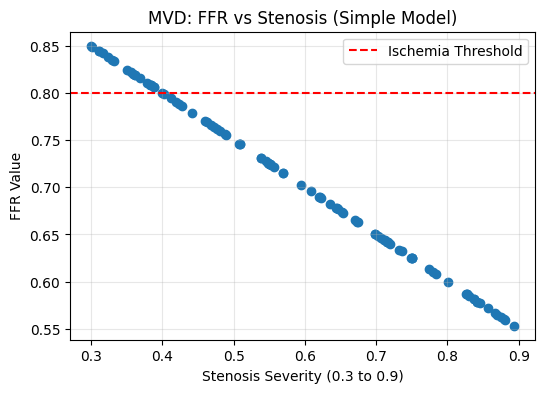

MVD created: 100 samples. Confirmed basic inverse relationship.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate 100 random stenosis values (our single feature)
np.random.seed(1)
N_SAMPLES = 100
stenosis_severity = np.random.uniform(0.3, 0.9, N_SAMPLES)

# 2. Simulate FFR using a simple, non-physical model
# FFR = 1.0 - (severity * 0.5)
ffr_simple = 1.0 - (stenosis_severity * 0.5)

# 3. Create a minimal DataFrame
mvd_data = pd.DataFrame({
    'stenosis_severity': stenosis_severity,
    'ffr_true': ffr_simple
})

# 4. Plot the result to check for sanity
plt.figure(figsize=(6, 4))
plt.scatter(mvd_data['stenosis_severity'], mvd_data['ffr_true'])
plt.axhline(y=0.80, color='red', linestyle='--', label='Ischemia Threshold')
plt.title("MVD: FFR vs Stenosis (Simple Model)")
plt.xlabel("Stenosis Severity (0.3 to 0.9)")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"MVD created: {mvd_data.shape[0]} samples. Confirmed basic inverse relationship.")


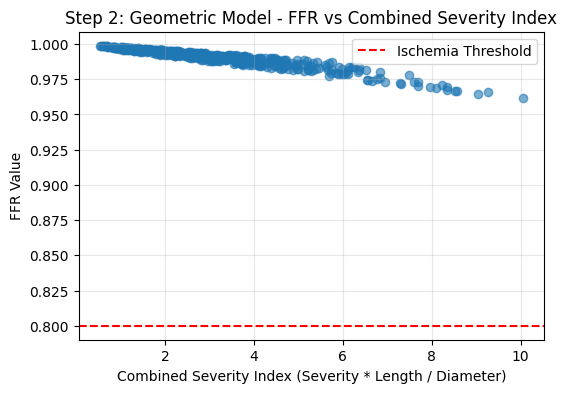

In [8]:

# STEP 2: The complexity check
# Goal: Introduce multiple anatomical features and non-linear interaction

N_SAMPLES = 500
np.random.seed(2)

# 1. Generate 3 key geometric features
stenosis_severity = np.random.uniform(0.3, 0.9, N_SAMPLES)
lesion_length = np.random.uniform(5, 30, N_SAMPLES) # mm
reference_diameter = np.random.uniform(2.5, 4.5, N_SAMPLES) # mm

# 2. Simulate FFR using a non-linear formula (e.g., incorporating length and diameter)
# FFR = 1.0 - (Severity * Length / Diameter^2) * 0.01 - A more complex, but still simplified model
ffr_geometric = 1.0 - (stenosis_severity * lesion_length / (reference_diameter**2)) * 0.01
ffr_geometric = np.clip(ffr_geometric, 0.4, 1.0) # Clip to realistic FFR range

# 3. Create a DataFrame
geometric_data = pd.DataFrame({
    'stenosis_severity': stenosis_severity,
    'lesion_length': lesion_length,
    'reference_diameter': reference_diameter,
    'ffr_true': ffr_geometric
})

# 4. Plot the result (FFR vs a combined severity index)
severity_index = (geometric_data['stenosis_severity'] * geometric_data['lesion_length']) / geometric_data['reference_diameter']
plt.figure(figsize=(6, 4))
plt.scatter(severity_index, geometric_data['ffr_true'], alpha=0.6)
plt.axhline(y=0.80, color='red', linestyle='--', label='Ischemia Threshold')
plt.title("Step 2: Geometric Model - FFR vs Combined Severity Index")
plt.xlabel("Combined Severity Index (Severity * Length / Diameter)")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
